In [1]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demesdraw
import demes

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [5]:
# Load best-fit models and data

u = 1.3e-8

graph_null_chag = "results/null_model_chag_Bherer_4.yaml"
graph_null_vin = "results/null_model_vin_Bherer_8.yaml"
graph_marg_chag = "results/marg_model_chag_Bherer_0.yaml"
graph_marg_vin = "results/marg_model_vin_Bherer_7.yaml"
graph_admix_chag = "results/admix_model_chag_Bherer_3.yaml"
graph_admix_vin = "results/admix_model_vin_Bherer_5.yaml"

data_file = "../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data_chag = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_null_chag, return_dict=True)
data_vin = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_null_vin, return_dict=True)

null_chag = dpluspy.inference.compute_bin_stats(graph_null_chag, 
    sampled_demes=data_chag["pop_ids"], bins=data_chag["bins"], u=u)
null_vin = dpluspy.inference.compute_bin_stats(graph_null_vin, 
    sampled_demes=data_vin["pop_ids"], bins=data_vin["bins"], u=u)

marg_chag = dpluspy.inference.compute_bin_stats(graph_marg_chag, 
    sampled_demes=data_chag["pop_ids"], bins=data_chag["bins"], u=u)
marg_vin = dpluspy.inference.compute_bin_stats(graph_marg_vin, 
    sampled_demes=data_vin["pop_ids"], bins=data_vin["bins"], u=u)

admix_chag = dpluspy.inference.compute_bin_stats(graph_admix_chag, 
    sampled_demes=data_chag["pop_ids"], bins=data_chag["bins"], u=u)
admix_vin = dpluspy.inference.compute_bin_stats(graph_admix_vin, 
    sampled_demes=data_vin["pop_ids"], bins=data_vin["bins"], u=u)

ll_null_chag = dpluspy.inference.composite_ll(
    null_chag, data_chag["means"], data_chag["varcovs"])
ll_marg_chag = dpluspy.inference.composite_ll(
    marg_chag, data_chag["means"], data_chag["varcovs"])
ll_admix_chag = dpluspy.inference.composite_ll(
    admix_chag, data_chag["means"], data_chag["varcovs"])

ll_null_vin = dpluspy.inference.composite_ll(
    null_vin, data_vin["means"], data_vin["varcovs"])
ll_marg_vin = dpluspy.inference.composite_ll(
    marg_vin, data_vin["means"], data_vin["varcovs"])
ll_admix_vin = dpluspy.inference.composite_ll(
    admix_vin, data_vin["means"], data_vin["varcovs"])

In [7]:
print(f"ll null Chagyrskaya:\t{ll_null_chag:.3}")
print(f"ll null Vindija:\t{ll_null_vin:.3}")
print(f"ll marg Chagyrskaya:\t{ll_marg_chag:.3}")
print(f"ll marg Vindija:\t{ll_marg_vin:.3}")
print(f"ll admix Chagyrskaya:\t{ll_admix_chag:.3}")
print(f"ll admix Vindija:\t{ll_admix_vin:.3}")

ll null Chagyrskaya:	-1.12e+03
ll null Vindija:	-1.15e+03
ll marg Chagyrskaya:	-4.87e+02
ll marg Vindija:	-5.07e+02
ll admix Chagyrskaya:	-4.83e+02
ll admix Vindija:	-5e+02


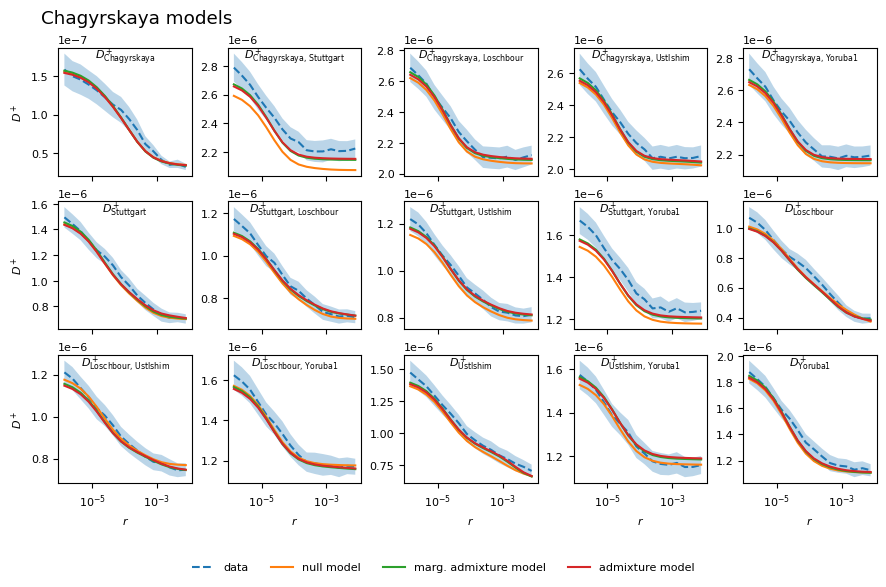

In [10]:
dpluspy.plotting.plot_D_plus_curves(
    models=[null_chag, marg_chag, admix_chag],
    pop_ids=data_chag["pop_ids"], 
    bins=data_chag["bins"], 
    means=data_chag["means"], 
    varcovs=data_chag["varcovs"], 
    labels=["data", "null model", "marg. admixture model", "admixture model"],
    title="Chagyrskaya models",
    out="figures/best_fits_chagyrskaya.pdf",
    ax_size=1.75
)

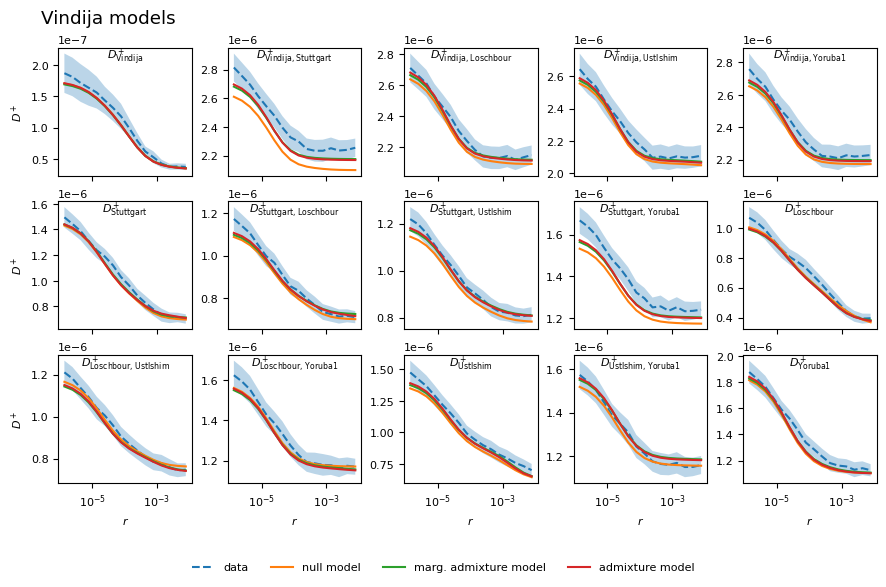

In [11]:
dpluspy.plotting.plot_D_plus_curves(
    models=[null_vin, marg_vin, admix_vin],
    pop_ids=data_vin["pop_ids"], 
    bins=data_vin["bins"], 
    means=data_vin["means"], 
    varcovs=data_vin["varcovs"], 
    labels=["data", "null model", "marg. admixture model", "admixture model"],
    title="Vindija models",
    out="figures/best_fits_vindija.pdf",
    ax_size=1.75
)

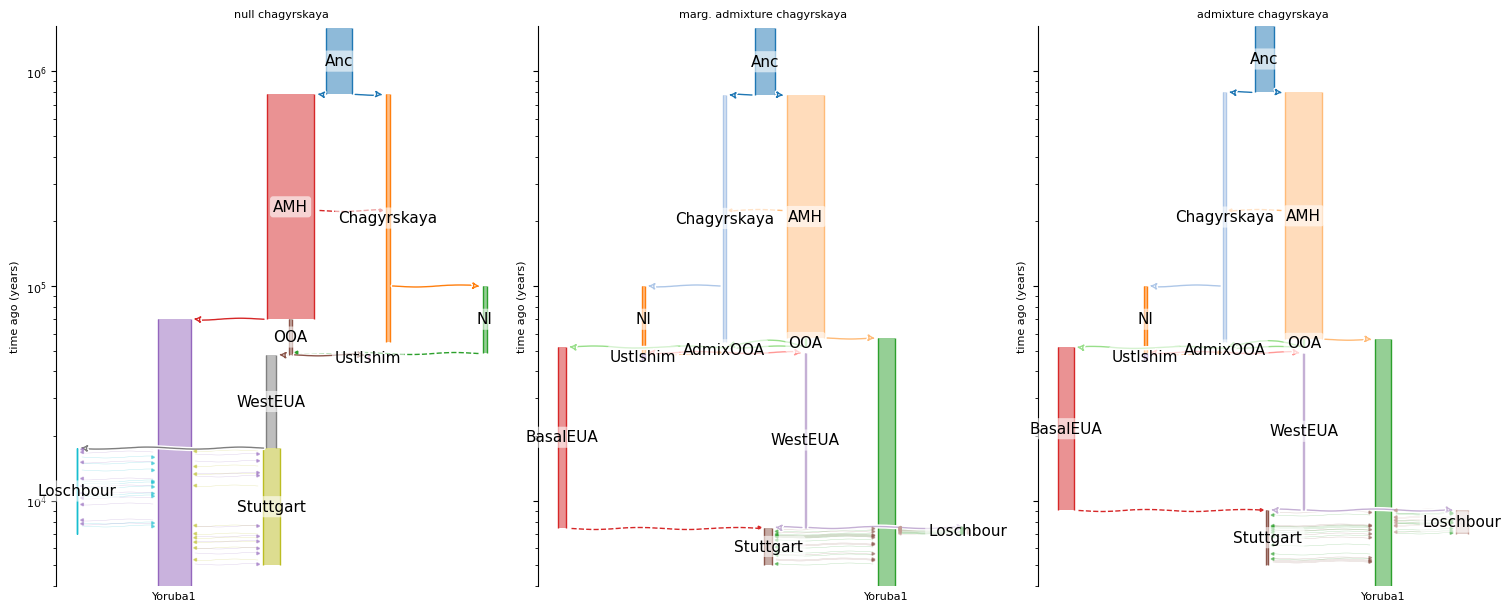

In [41]:
fig, axs = plt.subplots(1, 3, layout="constrained", figsize=(15,6), sharey=True)
axs = axs.flat

demesdraw.tubes(demes.load(graph_null_chag), ax=axs[0], log_time=True, inf_ratio=0.05, title="null chagyrskaya")
demesdraw.tubes(demes.load(graph_marg_chag), ax=axs[1], log_time=True, inf_ratio=0.05, title="marg. admixture chagyrskaya")
demesdraw.tubes(demes.load(graph_admix_chag), ax=axs[2], log_time=True, inf_ratio=0.05, title="admixture chagyrskaya")
axs[0].set_ylim(4000,)
plt.savefig("figures/best_fit_graphs_chagyrskaya.pdf")

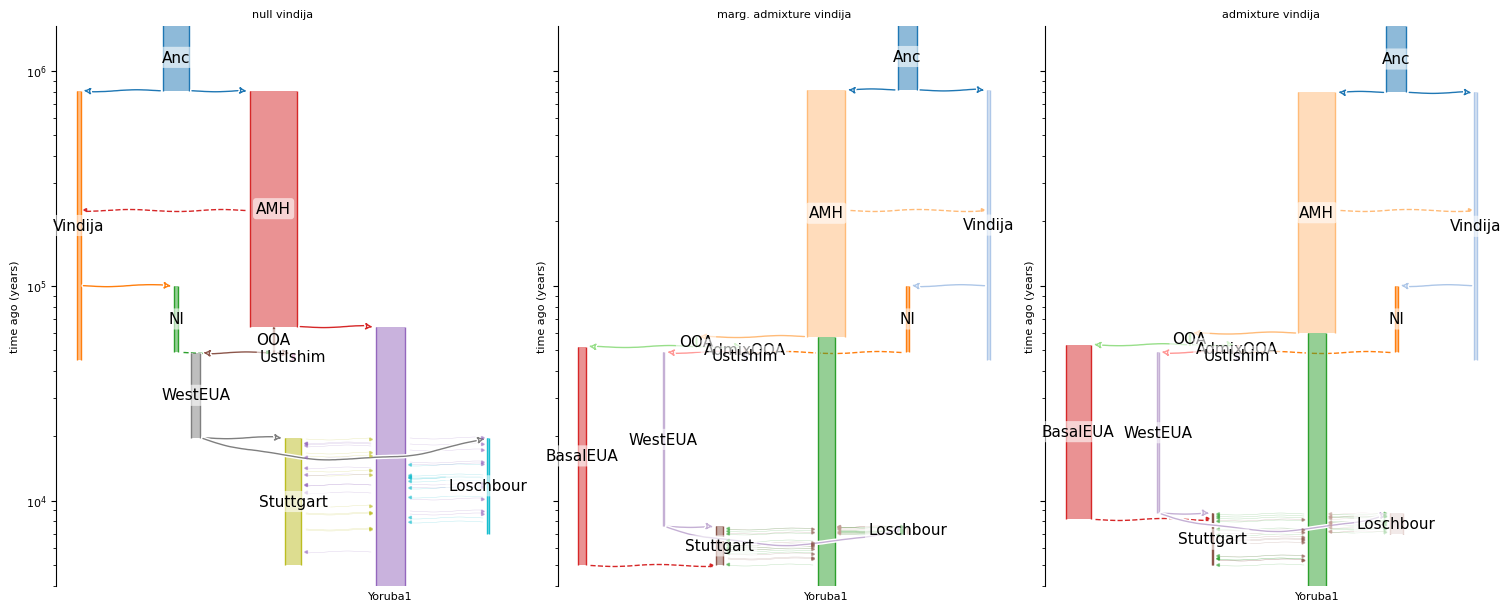

In [40]:
fig, axs = plt.subplots(1, 3, layout="constrained", figsize=(15,6), sharey=True)
axs = axs.flat

demesdraw.tubes(demes.load(graph_null_vin), ax=axs[0], log_time=True, inf_ratio=0.05, title="null vindija")
demesdraw.tubes(demes.load(graph_marg_vin), ax=axs[1], log_time=True, inf_ratio=0.05, title="marg. admixture vindija")
demesdraw.tubes(demes.load(graph_admix_vin), ax=axs[2], log_time=True, inf_ratio=0.05, title="admixture vindija")
axs[0].set_ylim(4000,)
plt.savefig("figures/best_fit_graphs_vindija.pdf")

In [31]:
graphs = [
    "results/null_model_chag_Bherer_4.yaml",
    "results/null_model_vin_Bherer_8.yaml",
    "results/marg_model_chag_Bherer_0.yaml",
    "results/marg_model_vin_Bherer_7.yaml",
    "results/admix_model_chag_Bherer_3.yaml",
    "results/admix_model_vin_Bherer_5.yaml"
]
params = [
    "models/null_model_chag_params.yaml",
    "models/null_model_vin_params.yaml",
    "models/marg_model_chag_params.yaml",
    "models/marg_model_vin_params.yaml",
    "models/admix_model_chag_params.yaml",
    "models/admix_model_vin_params.yaml",
]

dfs = []

for graph, params in zip(graphs, params):
    pnames, params = dpluspy.inference._load_params(graph, params)
    pdict = {"model": graph}
    pdict.update({pname: [p] for pname, p in zip(pnames, params)})
    dfs.append(pandas.DataFrame(pdict))

param_df = pandas.concat(dfs)

In [43]:
param_df.to_csv("MLE_parameters.csv")
print(param_df.to_string())

                                    model           T_NH         T_OOA         T_Ust      T_LosStu  p_AMH_Cha      m_StuYor  m_LosYor         N_Anc          N_N         N_AMH         N_Yor        N_OOA       N_WEUA         N_Stu        N_Ust         N_Los       T_Basal    T_Bas_Stu  p_Bas_Stu        N_BEUA
0   results/null_model_chag_Bherer_4.yaml  780284.290567  70016.447144  47779.855986  17582.069009   0.074115  1.586601e-04  0.000066  15711.922240  2442.323300  28202.670262  19516.765161  1480.322799  5711.076158  10000.000000   622.472446    510.210290           NaN          NaN        NaN           NaN
0    results/null_model_vin_Bherer_8.yaml  807082.857351  64513.018542  48652.067592  19618.872873   0.098869  1.481003e-04  0.000056  15514.991596  2351.976324  28394.691806  17706.923789  1037.104653  5546.415196  10000.000000   766.906156    612.616418           NaN          NaN        NaN           NaN
0   results/marg_model_chag_Bherer_0.yaml  775431.425872  57244.287873  4896